In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cpu


In [3]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

In [4]:
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import pandas as pd
import time

In [11]:
img_path = "C:/Users/syj43/q_seg/datasets/road_sample/images/"
label_path = "C:/Users/syj43/q_seg/datasets/road_sample/labels/"
img_files = [f for f in os.listdir(img_path) if f.startswith("sat") or f.startswith("sat")]
label_files = [f for f in os.listdir(label_path) if f.startswith("mask") or f.startswith("mask")] # ground truth

images, labels = [], []
for i in range(len(img_files)):
    image = cv2.imread(img_path + img_files[i], cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    images.append(image)
    label = cv2.imread(label_path + label_files[i], cv2.IMREAD_GRAYSCALE) / 255.0
    labels.append(label)

In [12]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(sam2)

In [13]:
def show_all_masks(masks):
    # Suppose masks is a list of dictionaries, each with a 'segmentation' key
    num_masks = len(masks)

    # Create a grid layout (adjust cols/rows as needed)
    cols = 4
    rows = (num_masks + cols - 1) // cols  # ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))

    # Flatten axes for easy iteration
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < num_masks:
            ax.imshow(masks[i]['segmentation'])
            ax.set_title(f"Mask {i}")
            ax.axis("off")
        else:
            ax.axis("off")  # hide unused subplots

    plt.tight_layout()
    plt.show()

Example run

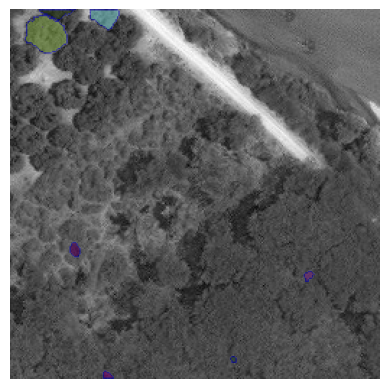

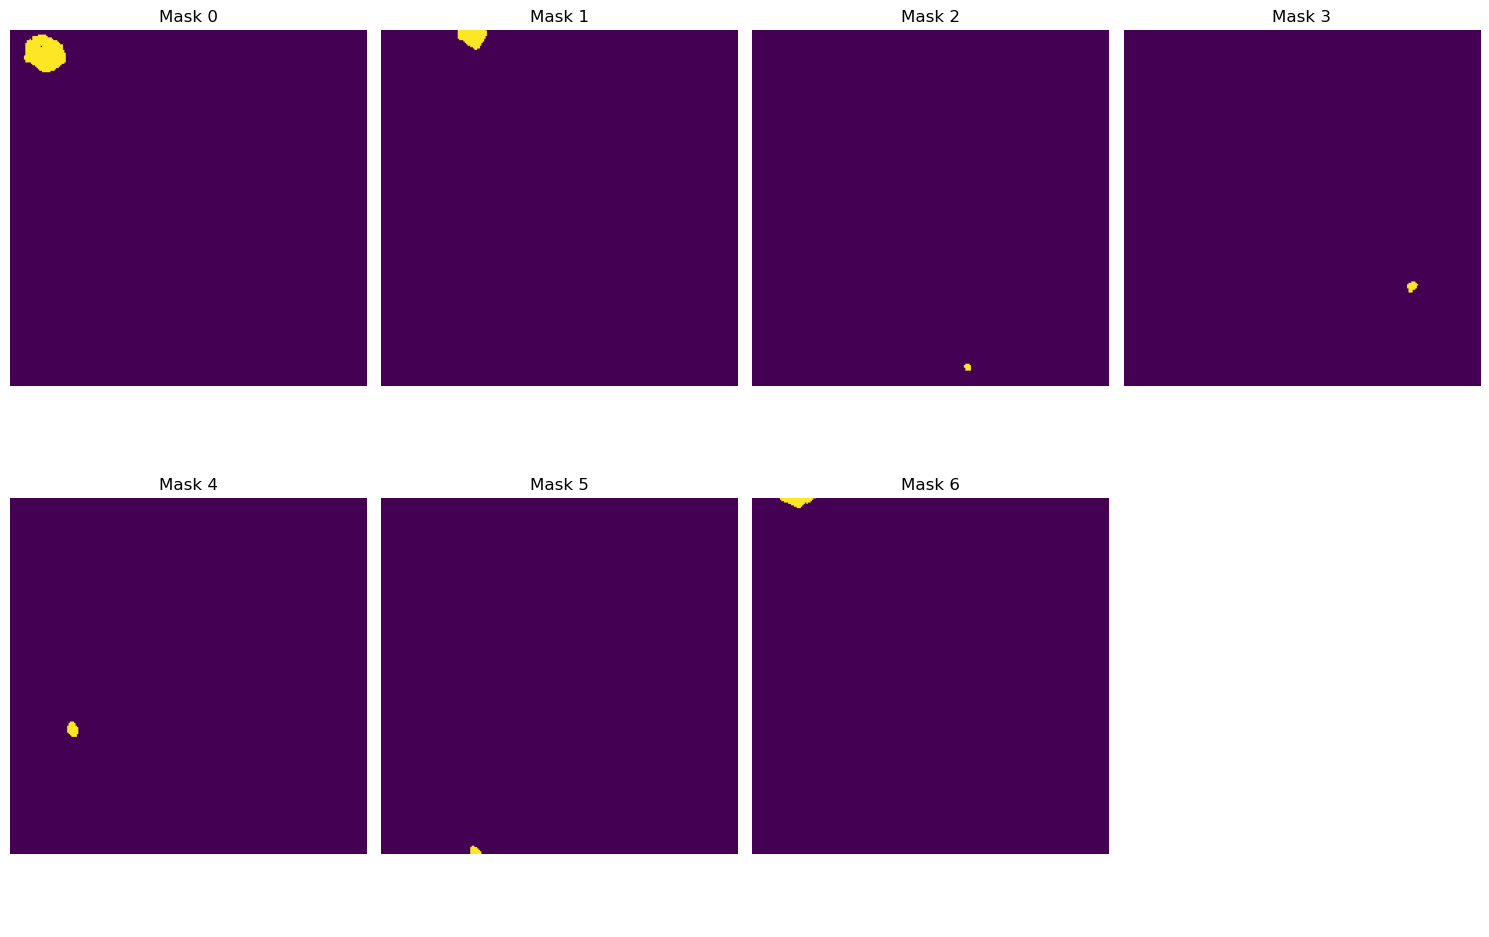

In [14]:
idx = 0
image = images[idx]
plt.imshow(image)
masks = mask_generator.generate(image)
show_anns(masks)
plt.axis('off')
plt.show()

show_all_masks(masks)

In [15]:
def get_metrics(labels, idx, best_idx, masks):
    y_true = labels[idx].astype(int).ravel()
    y_pred = masks[best_idx]['segmentation'].astype(int).ravel()
    accuracy = round(accuracy_score(y_true, y_pred), 3)
    iou = round(jaccard_score(y_true, y_pred, average='macro',  zero_division=1), 3)
    precision = round(precision_score(y_true, y_pred, average='macro', zero_division=1), 3)
    recall = round(recall_score(y_true, y_pred, average='macro', zero_division=1), 3)
    f1 = round(f1_score(y_true, y_pred, average='macro',  zero_division=1), 3)
    return [accuracy, iou, precision, recall, f1]

def add_highest_iou(labels, idx, masks):
    y_true = labels[idx].astype(int).ravel()
    
    l_iou = []
    for i in range(len(masks)):
        y_pred = masks[i]['segmentation'].astype(int).ravel()
        iou = round(jaccard_score(y_true, y_pred, average='macro',  zero_division=1), 3)
        l_iou.append(iou)
        
    best_idx = np.argmax(l_iou)
    l_metrics = get_metrics(labels, idx, best_idx, masks)
    return l_metrics

In [16]:
# get the mask with the highest iou and compare it with the ground truth.
add_highest_iou(labels, idx, masks)

[0.967, 0.484, 0.484, 0.5, 0.492]

Test on the whole set

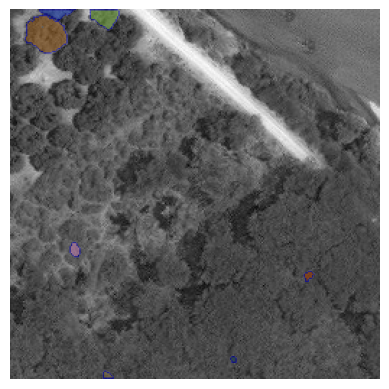

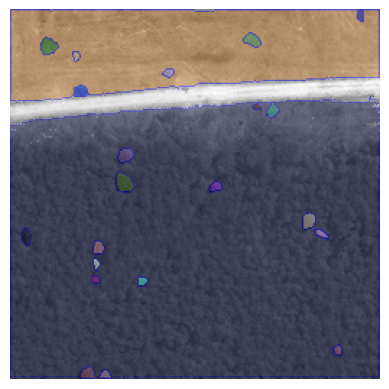

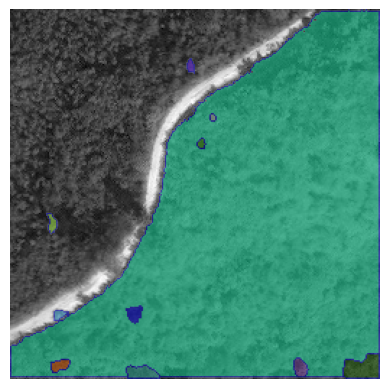

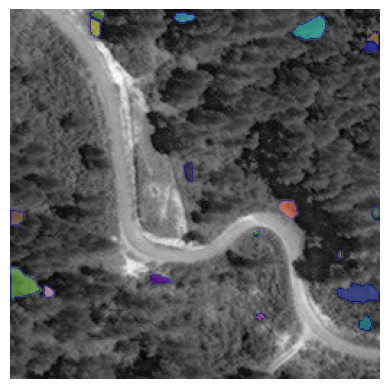

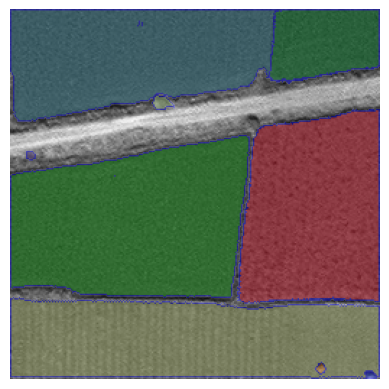

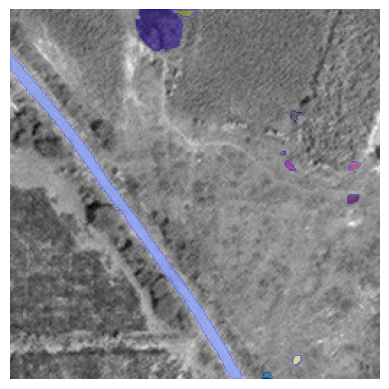

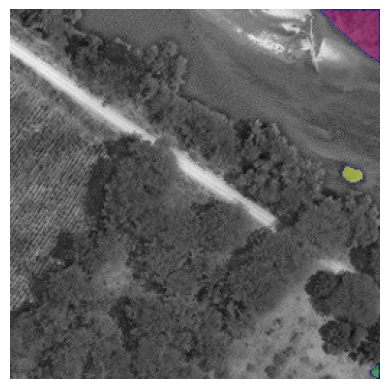

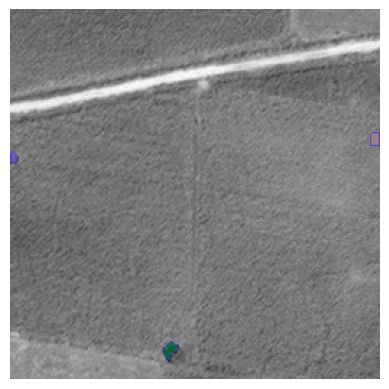

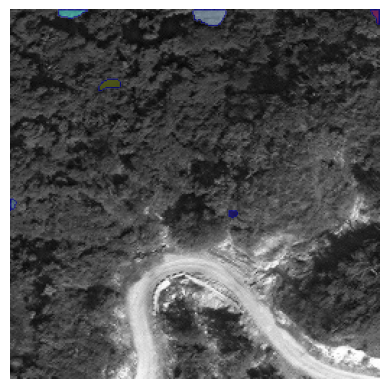

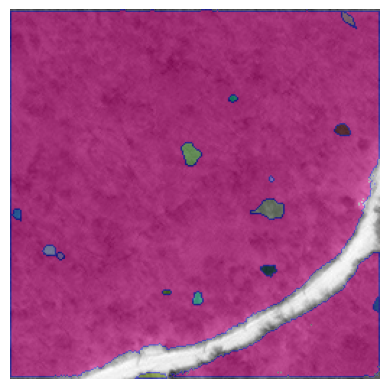

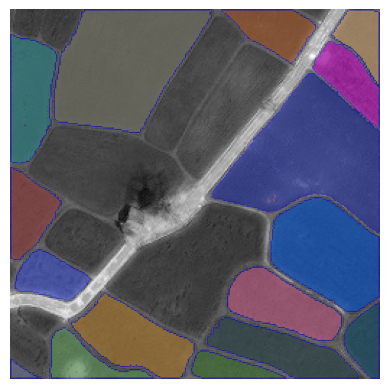

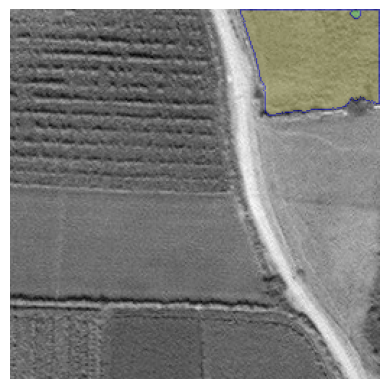

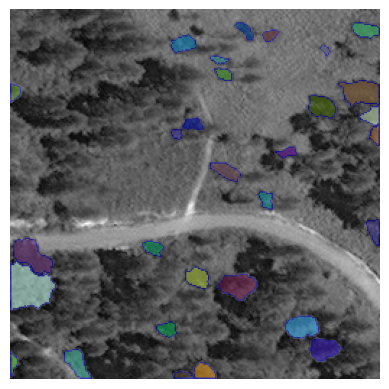

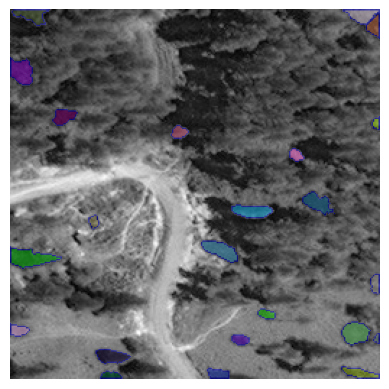

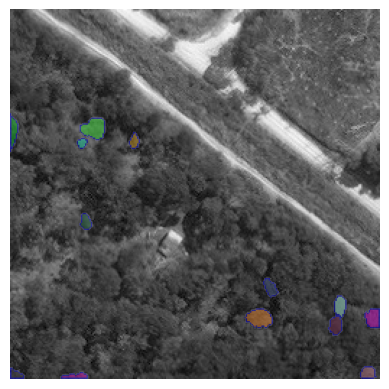

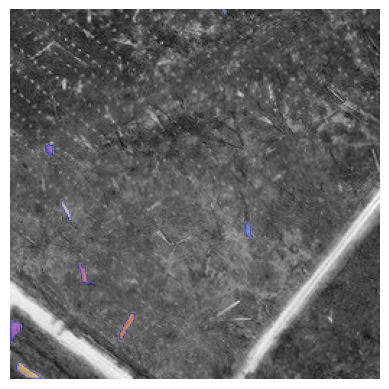

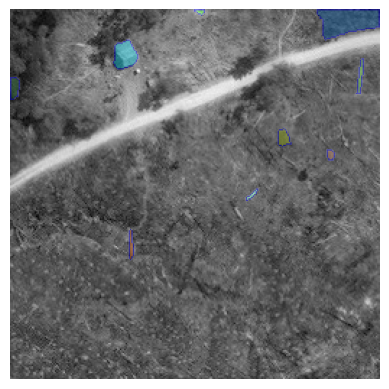

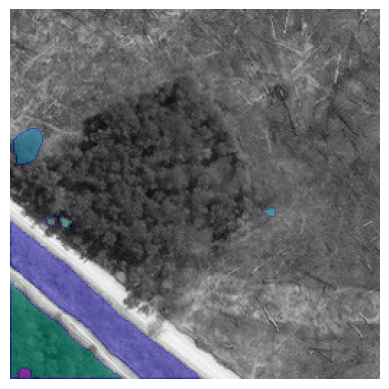

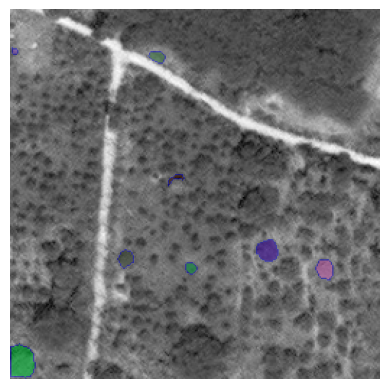

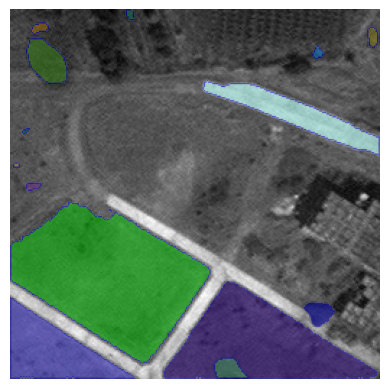

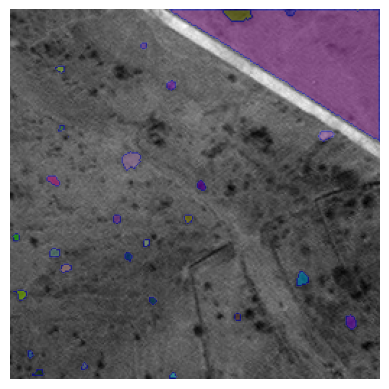

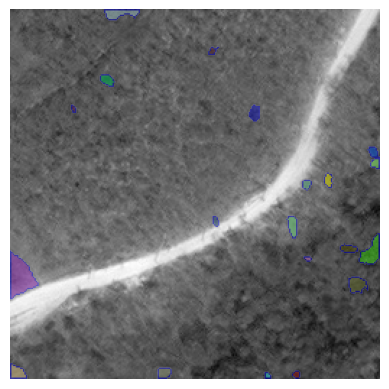

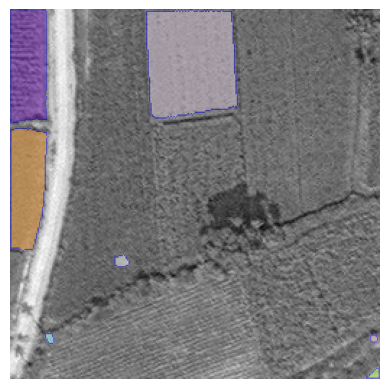

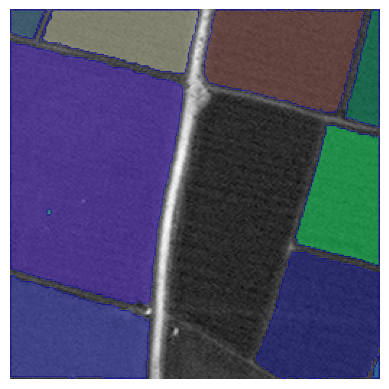

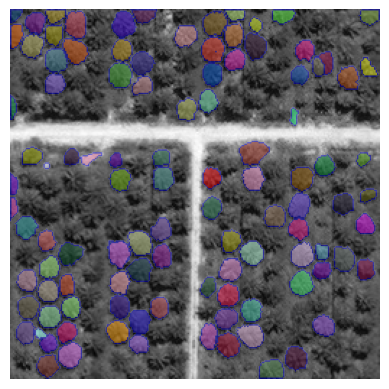

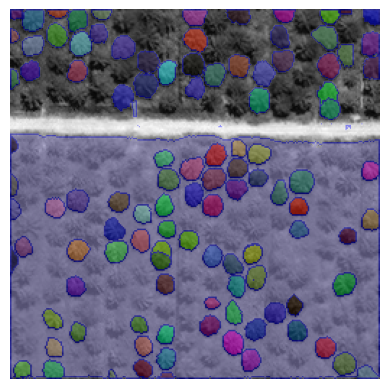

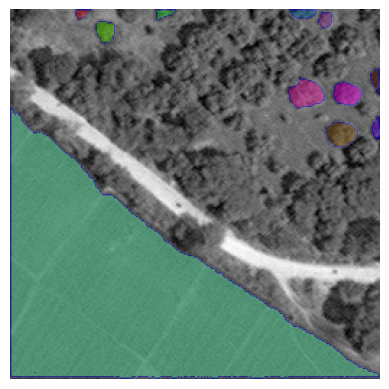

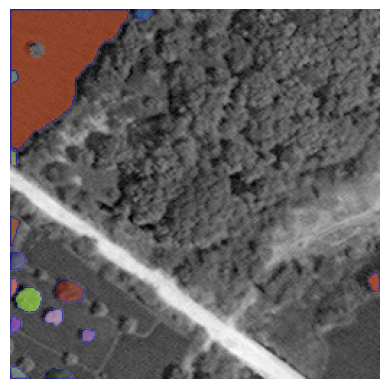

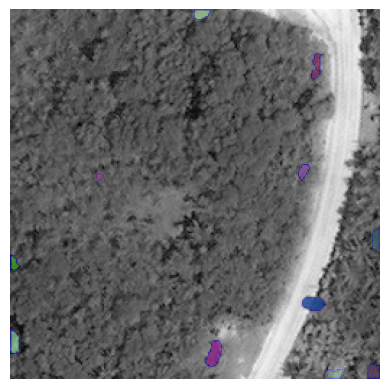

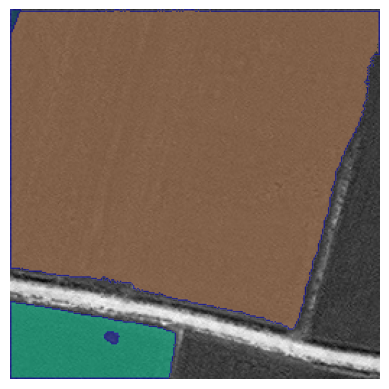

In [17]:
df = pd.DataFrame(columns=['idx', 'accuracy', 'iou', 'precision', 'recall', 'f1', 'runtime'])
l_runtime = []

for i in range(30):
    image = images[i]
    
    start = time.time()
    masks = mask_generator.generate(image)
    end = time.time()
    
    plt.imshow(image)
    show_anns(masks)
    plt.axis('off')
    plt.show()
    
    df.loc[len(df)] = [i] + add_highest_iou(labels, i, masks) + [round(end-start,3)]

In [18]:
df.to_csv('road_sam.csv') # start from here

In [19]:
df.describe().loc[['mean', '50%']].round(3)

,idx,accuracy,iou,precision,recall,f1,runtime
mean,14.5,0.95,0.494,0.55,0.52,0.511,32.718
50%,14.5,0.95,0.479,0.48,0.50,0.490,32.638


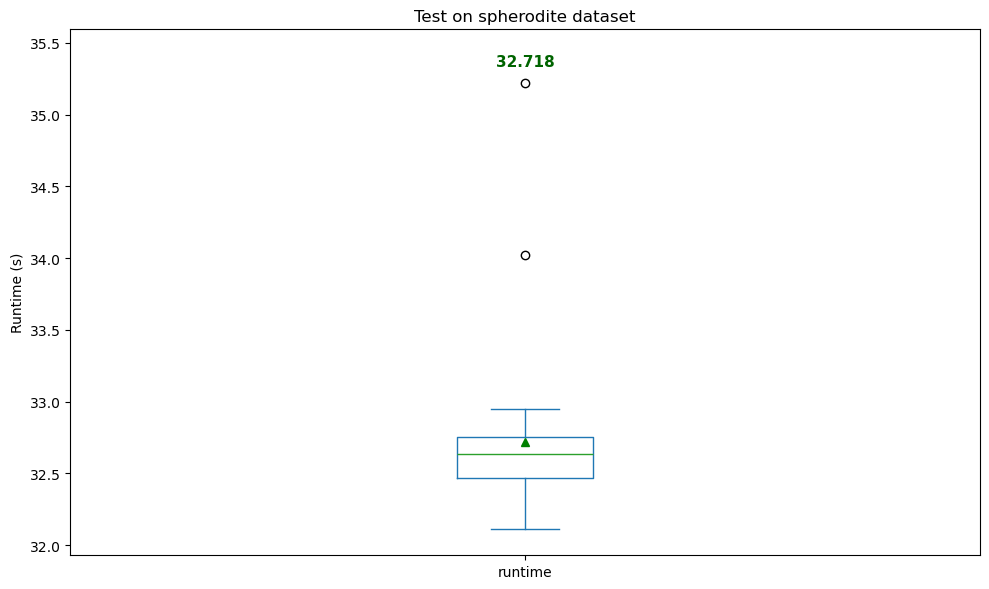

In [21]:
if 'idx' in df.columns:
    df_runtime = df.set_index('idx')

df_runtime = df_runtime[['runtime']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

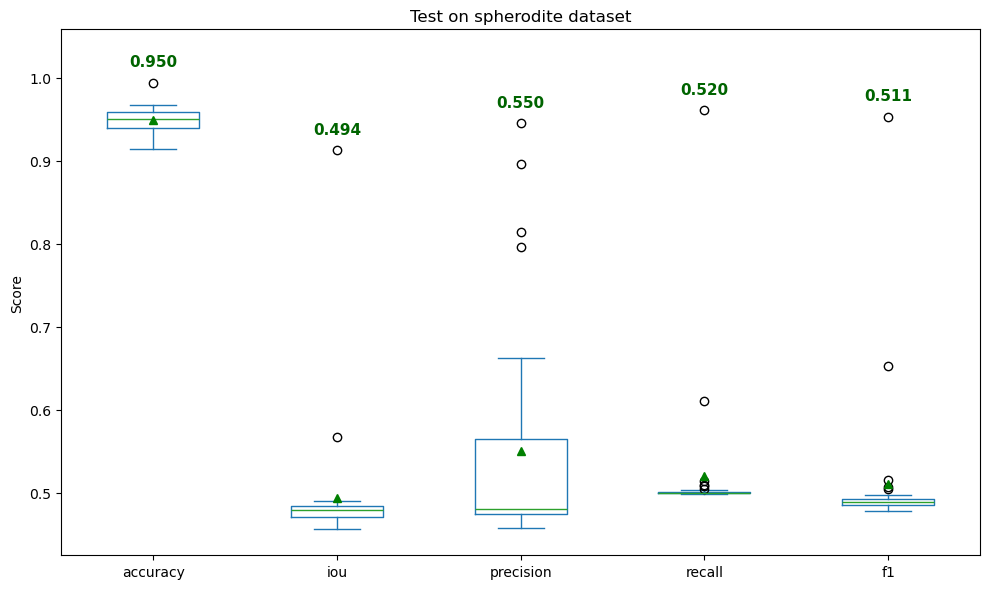

In [22]:
df.drop(columns=['idx', 'runtime'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df.values.max() - df.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df.columns, start=1):
    mean_val = df[col].mean()
    max_val = df[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df.values.min() - y_offset * 2, df.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()